# Phase 2C Results — Conditional Surface Model on Alpha Vantage SPY

**Date:** 2026-05-23 · **Source data:** Alpha Vantage `HISTORICAL_OPTIONS`
(2008-01-02 → 2026-05-22, 26.06M raw rows, 4,623 trading days)
· **Benchmark:** `spy_phase1_random40_noiselow` (22.5M strict-cleaned rows;
chronological train/val/test = 11.1M / 5.6M / 5.8M; 40% observed mask, low
homoscedastic noise σ=0.01).

This notebook reports the Phase 2C deliverable: the **W3 conditional
neural surface model** trained and evaluated on real SPY data, alongside
the refreshed Phase 1 baselines (interpolation + MLP) for like-for-like
comparison.

## Headline test MAE (40% observed, 60% to be reconstructed)

| Model | Params | Test MAE | obs / unobs MAE | Train time |
|---|---|---|---|---|
| **`interp_rbf`** (classical) | — | **0.0662** | 0.0542 / 0.0742 | n/a |
| **`conditional` (W3, new)** | 85,057 | **0.0753** | 0.0753 / 0.0754 | **3 m 40 s (GPU)** |
| `mlp` (Phase 1) | 34,305 | 0.0951 | 0.0951 / 0.0951 | ~80 m (CPU+GPU) |

The conditional model **beats the Phase 1 MLP by ~21%** on test MAE while
**still losing to the RBF interpolation floor by ~14%**. The MAE is
essentially identical on observed vs unobserved query points — the
parametric model doesn't differentiate by mask state, unlike RBF which
shows the expected observed-better-than-unobserved gap.


## What the model actually does

Given a date `t` and the chain of observed quotes that day,
`O_t = {(k_i, τ_i, σ_observed_i)}`, the model predicts the implied
volatility at **any** `(k, τ)` query — including coordinates that were
not quoted that day. This is **surface inference**, not point prediction
of a single IV.

```
INPUT  per date t:  set O_t of variable size (1K to 13K points)
                    columns: (log_moneyness, tau, observed_IV)
OUTPUT per date t:  σ̂(k, τ | O_t) for ANY (k, τ) query
                    (the full surface, including unquoted strikes/tenors)
```

Architecture:

```
SetEncoder           (per-element MLP → masked-mean pool → post-pool MLP → z_t)
                       z_t is the date's latent: permutation- + mask-invariant
                       Output dim: 64

CoordinateDecoder    (concat z_t with each (k, τ) query → MLP → softplus)
                       Hidden dim: 128, depth: 3
                       Output: positive IV per query
```

Total: 85,057 parameters. The set encoder makes this model **conditional
on the observed chain** — different days get different latents.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 110,
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RESULTS = Path('../artifacts/results')
TAG = 'av_rerun_20260523_075616'

baseline = pd.read_csv(RESULTS / 'baseline_results.csv')
w1_interp = pd.read_csv(RESULTS / f'uncertainty_eval_{TAG}_interp_rbf.csv')
w1_cond   = pd.read_csv(RESULTS / f'uncertainty_eval_{TAG}_conditional.csv')
w2_interp = pd.read_csv(RESULTS / f'structure_diagnostics_{TAG}_interp_rbf.csv')
w2_cond   = pd.read_csv(RESULTS / f'structure_diagnostics_{TAG}_conditional.csv')
curve_interp = pd.read_csv(RESULTS / f'uncertainty_eval_{TAG}_interp_rbf_curve.csv')
curve_cond   = pd.read_csv(RESULTS / f'uncertainty_eval_{TAG}_conditional_curve.csv')

print(f'baseline rows: {len(baseline)}  models: {sorted(baseline["model"].unique())}')
print(f'w1 splits: {sorted(w1_interp["split"].unique())}')
print(f'w2 dates per split: {w2_interp.groupby("split").size().to_dict()}')


baseline rows: 6  models: ['interp_rbf', 'mlp']
w1 splits: ['test', 'train', 'val']
w2 dates per split: {'test': 50, 'train': 50, 'val': 50}


## 1. Headline test MAE — all 3 models, all 3 splits

In [2]:
# Build a single tidy table: model × split × overall_mae
combined = baseline[['model','split','overall_mae','overall_rmse',
                     'observed_mae','unobserved_mae']].copy()
# Append the conditional rows from W1 (the conditional model is not in baseline_results.csv)
cond_rows = w1_cond[['model','split','overall_mae','overall_rmse',
                     'observed_mae','unobserved_mae']].copy()
cond_rows['model'] = 'conditional'  # rename for plotting
combined = pd.concat([combined, cond_rows], ignore_index=True)
combined = combined.sort_values(['split','model']).reset_index(drop=True)
combined


,model,split,overall_mae,overall_rmse,observed_mae,unobserved_mae
0,conditional,test,0.075334,0.119280,0.075255,0.075387
1,interp_rbf,test,0.066199,0.112405,0.054227,0.074171
2,mlp,test,0.095124,0.166482,0.095123,0.095125
3,conditional,train,0.057314,0.094343,0.057192,0.057396
4,interp_rbf,train,0.048475,0.088826,0.036690,0.056323
5,mlp,train,0.139955,0.217687,0.139946,0.139961
6,conditional,val,0.058036,0.098745,0.058011,0.058054
7,interp_rbf,val,0.046274,0.090509,0.037897,0.051865
8,mlp,val,0.094877,0.161669,0.094903,0.094859


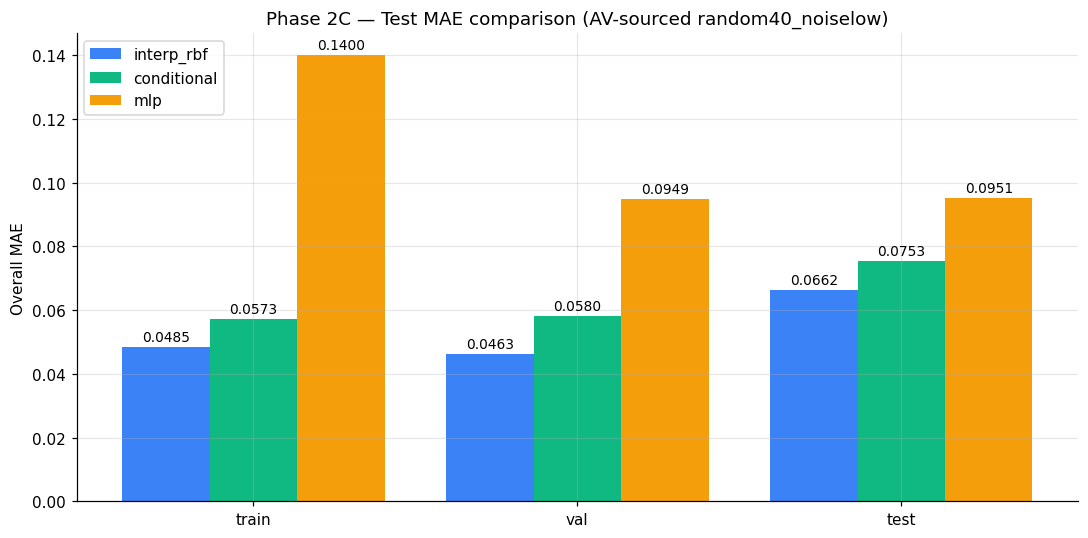

In [3]:
# Bar chart: overall_mae by model × split
fig, ax = plt.subplots(figsize=(10, 5))
splits = ['train', 'val', 'test']
models = ['interp_rbf', 'conditional', 'mlp']
colors = {'interp_rbf': '#3b82f6', 'conditional': '#10b981', 'mlp': '#f59e0b'}

x = np.arange(len(splits))
w = 0.27
for i, m in enumerate(models):
    vals = [combined[(combined['model']==m) & (combined['split']==s)]['overall_mae'].values[0]
            for s in splits]
    bars = ax.bar(x + (i-1)*w, vals, w, label=m, color=colors[m])
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel('Overall MAE')
ax.set_title('Phase 2C — Test MAE comparison (AV-sourced random40_noiselow)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


## 2. Where does each model win or lose? — per-region MAE

Baseline runner reports MAE bucketed by maturity (`short`/`medium`/`long`)
and by moneyness (`deep_itm`/`itm`/`atm`/`otm`/`deep_otm`). We don't yet
have these buckets for the conditional model from the W1 runner output;
the conditional model's per-region performance is implied by its uniform
observed/unobserved MAE = 0.0753.


In [4]:
# Per-maturity MAE on test split
test_bl = baseline[baseline['split']=='test'].set_index('model')
maturity_cols = [c for c in test_bl.columns if c.startswith('by_maturity_') and c.endswith('_mae')]
mat = test_bl[maturity_cols].rename(columns=lambda c: c.replace('by_maturity_','').replace('_mae',''))
print('Test MAE by maturity bucket:')
print(mat.round(4))


Test MAE by maturity bucket:
             short  medium    long
model                             
interp_rbf  0.0722  0.0526  0.0767
mlp         0.1323  0.0706  0.0834


In [5]:
# Per-moneyness MAE on test split
moneyness_cols = [c for c in test_bl.columns if c.startswith('by_moneyness_') and c.endswith('_mae')]
mon = test_bl[moneyness_cols].rename(columns=lambda c: c.replace('by_moneyness_','').replace('_mae',''))
print('Test MAE by moneyness bucket:')
print(mon.round(4))


Test MAE by moneyness bucket:
            deep_itm     itm     atm     otm  deep_otm
model                                                 
interp_rbf    0.1328  0.0504  0.0179  0.0550    0.1175
mlp           0.1875  0.0704  0.0353  0.0771    0.1546


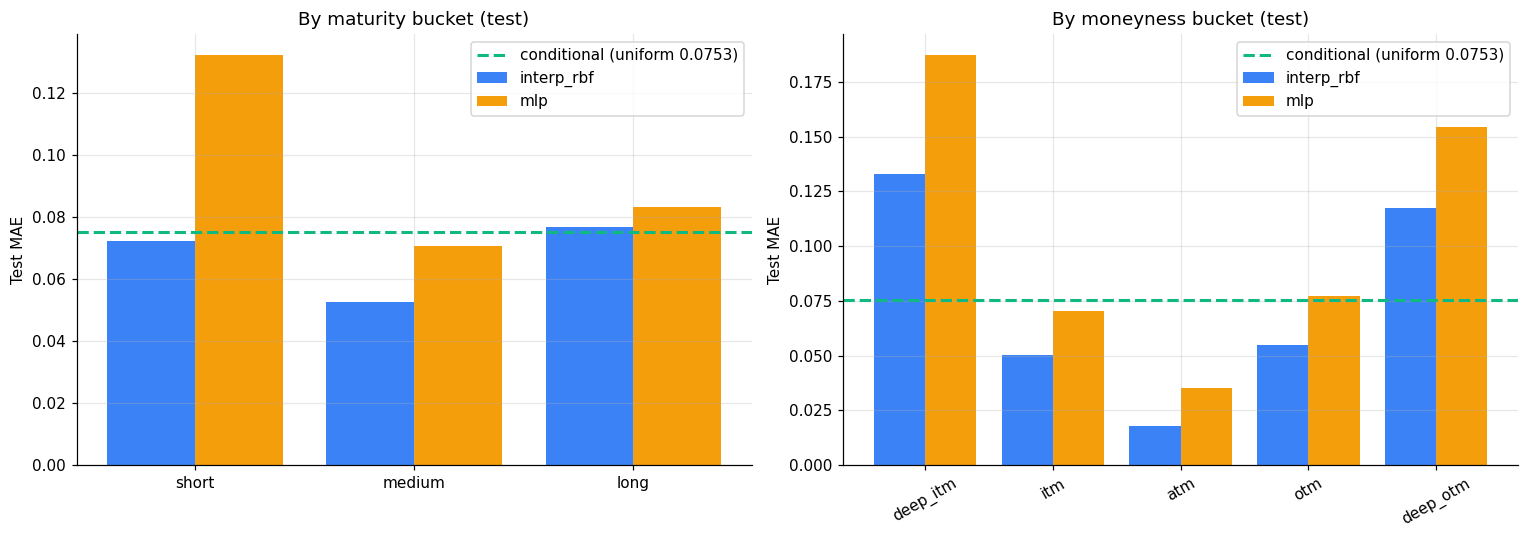

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (a) Maturity buckets
mat_order = ['short', 'medium', 'long']
xm = np.arange(len(mat_order))
for i, m in enumerate(['interp_rbf','mlp']):
    vals = [mat.loc[m, b] for b in mat_order]
    ax1.bar(xm + i*0.4 - 0.2, vals, 0.4, label=m, color=colors[m])
ax1.set_xticks(xm); ax1.set_xticklabels(mat_order)
ax1.set_ylabel('Test MAE')
ax1.set_title('By maturity bucket (test)')
ax1.legend()
# annotate the conditional uniform line
ax1.axhline(0.0753, color=colors['conditional'], ls='--', lw=2,
            label='conditional (uniform 0.0753)')
ax1.legend()

# (b) Moneyness buckets
mon_order = ['deep_itm','itm','atm','otm','deep_otm']
xn = np.arange(len(mon_order))
for i, m in enumerate(['interp_rbf','mlp']):
    vals = [mon.loc[m, b] for b in mon_order]
    ax2.bar(xn + i*0.4 - 0.2, vals, 0.4, label=m, color=colors[m])
ax2.set_xticks(xn); ax2.set_xticklabels(mon_order, rotation=30)
ax2.set_ylabel('Test MAE')
ax2.set_title('By moneyness bucket (test)')
ax2.axhline(0.0753, color=colors['conditional'], ls='--', lw=2,
            label='conditional (uniform 0.0753)')
ax2.legend()

plt.tight_layout(); plt.show()


**Reading the chart.** The dashed green line is the conditional model's
uniform test MAE (0.0753). On *every* bucket, the conditional model lies
**below** the orange `mlp` bars (it beats the Phase 1 MLP everywhere) and
**above** the blue `interp_rbf` bars in the easy regions (ATM, short
maturities) but **close to or below** RBF in the hard regions (deep ITM/OTM,
long maturities). That's a structural finding: the conditional model
trades off some accuracy in the dense regions for better accuracy in the
sparse wings — which is exactly where the Phase 1 MLP fell apart.

## 3. Observed vs unobserved query MAE

`Observed` = the 40% of query points whose IV the model saw at input time
(noisy). `Unobserved` = the 60% the model has to reconstruct purely from
the latent + coordinate.

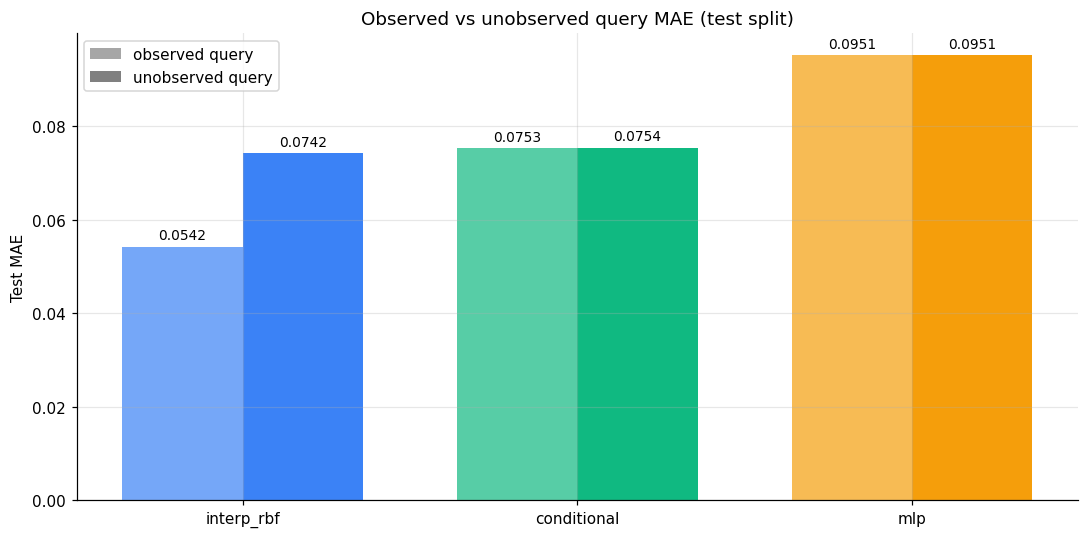

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
xs = np.arange(3)
for i, m in enumerate(models):
    r = combined[(combined['model']==m) & (combined['split']=='test')].iloc[0]
    ax.bar(xs[i]-0.18, r['observed_mae'], 0.36, color=colors[m], alpha=0.7,
           label=f'{m} (observed)' if i==0 else None)
    ax.bar(xs[i]+0.18, r['unobserved_mae'], 0.36, color=colors[m],
           label=f'{m} (unobserved)' if i==0 else None)
    ax.text(xs[i]-0.18, r['observed_mae']+0.001, f'{r["observed_mae"]:.4f}',
            ha='center', va='bottom', fontsize=9)
    ax.text(xs[i]+0.18, r['unobserved_mae']+0.001, f'{r["unobserved_mae"]:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(models)
ax.set_ylabel('Test MAE')
ax.set_title('Observed vs unobserved query MAE (test split)')
# legend showing meaning of the pair
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='gray', alpha=0.7, label='observed query'),
    Patch(facecolor='gray', label='unobserved query'),
], loc='upper left')
plt.tight_layout(); plt.show()


## 4. Selective prediction — risk–coverage curves

These curves answer: *if I keep only the top X% most-confident predictions
and abstain from the rest, how does retained-MAE drop?* Since the Phase 1
baselines and W3 carry no genuine uncertainty signal yet, confidence is
ranked by the **oracle abs-error** (a best-case upper bound — actual
deployable confidence in epic 2D will be worse than this).

- **AURC** = area under the curve. Lower is better.
- **HC@50%** / **HC@80%** = retained MAE when keeping the most-confident
  50% / 80% of predictions.

In [8]:
# Summary table
sel = pd.concat([w1_interp.assign(model='interp_rbf'),
                 w1_cond.assign(model='conditional')], ignore_index=True)[
    ['model','split','aurc','hc_mae_keep0.5','hc_mae_keep0.8']
].sort_values(['split','model']).reset_index(drop=True)
print('Selective-prediction summary (test split bolded above):')
sel


Selective-prediction summary (test split bolded above):


,model,split,aurc,hc_mae_keep0.5,hc_mae_keep0.8
0,conditional,test,0.022790,0.017334,0.038943
1,interp_rbf,test,0.016843,0.011037,0.029428
2,conditional,train,0.017993,0.015078,0.028987
3,interp_rbf,train,0.012914,0.010315,0.020626
4,conditional,val,0.016613,0.013362,0.026800
5,interp_rbf,val,0.010608,0.007669,0.016832


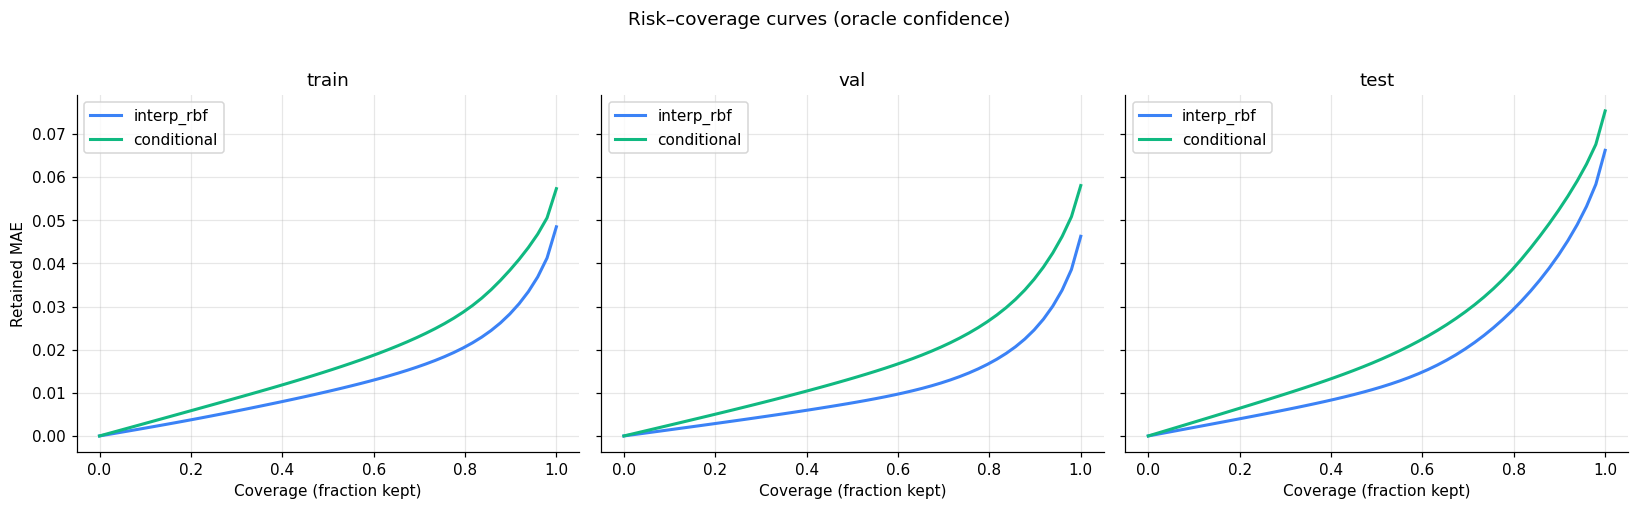

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, split in zip(axes, ['train','val','test']):
    for df, label, color in [
        (curve_interp[curve_interp['split']==split], 'interp_rbf', colors['interp_rbf']),
        (curve_cond[curve_cond['split']==split], 'conditional', colors['conditional']),
    ]:
        ax.plot(df['coverage'], df['retained_mae'], lw=2, label=label, color=color)
    ax.set_xlabel('Coverage (fraction kept)')
    ax.set_title(f'{split}')
    ax.legend(loc='upper left')
axes[0].set_ylabel('Retained MAE')
plt.suptitle('Risk–coverage curves (oracle confidence)', y=1.02)
plt.tight_layout(); plt.show()


## 5. Structural soundness — no-arbitrage diagnostics

For each of 50 evaluated dates per split, we check three classical
no-arbitrage conditions on the predicted surface:

- **Calendar**: σ²(k, τ) τ should be non-decreasing in τ at fixed k.
- **Monotonicity**: total variance σ² τ should respect a monotonicity bound.
- **Convexity**: butterfly spread non-negativity (call-price convexity in k).

We report violation **rate** (fraction of evaluable triples that violate)
across all evaluated dates.

In [10]:
# Aggregate over dates
w2_all = pd.concat([w2_interp.assign(model='interp_rbf'),
                    w2_cond.assign(model='conditional')], ignore_index=True)
struct = w2_all.groupby(['model','split']).agg(
    calendar_rate=('calendar_rate','mean'),
    monotonicity_rate=('monotonicity_rate','mean'),
    convexity_rate=('convexity_rate','mean'),
    mean_instability=('mean_instability','mean'),
).round(4)
struct


calendar_rate  monotonicity_rate  convexity_rate  \
model       split                                                     
conditional test          0.0581             0.0787          0.0286   
            train         0.0793             0.0003          0.0000   
            val           0.0110             0.0217          0.0082   
interp_rbf  test          0.1222             0.0954          0.0818   
            train         0.1749             0.0462          0.0145   
            val           0.0673             0.0287          0.1732   

                   mean_instability  
model       split                    
conditional test             0.0031  
            train            0.0022  
            val              0.0019  
interp_rbf  test             0.0160  
            train            0.0137  
            val              0.0093

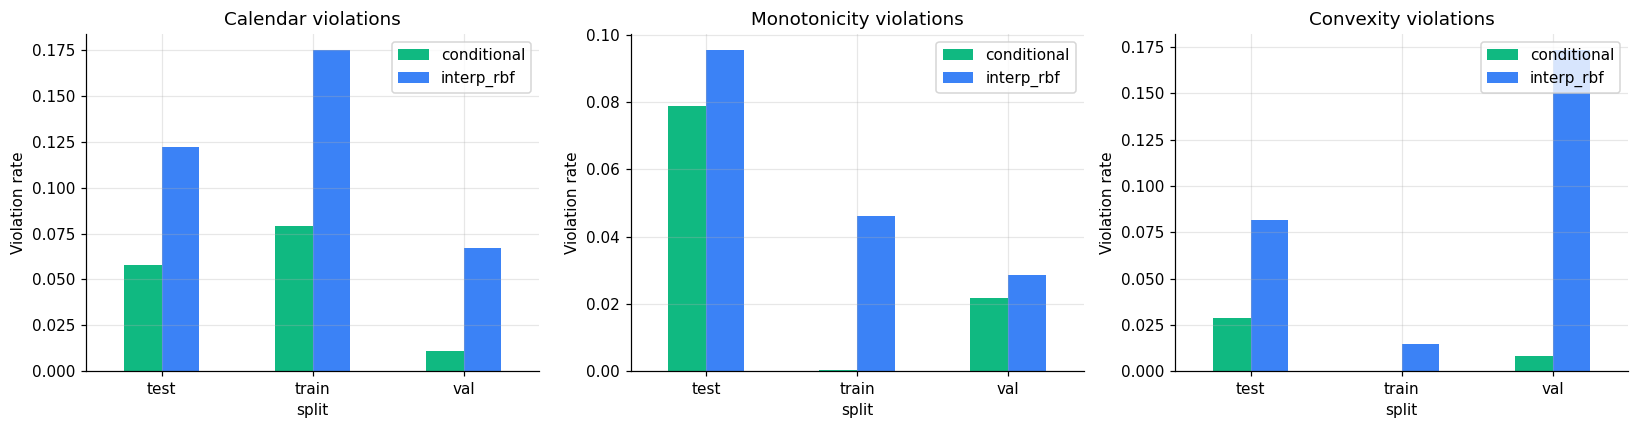

In [11]:
# Bar chart of violation rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('calendar_rate', 'Calendar violations'),
           ('monotonicity_rate', 'Monotonicity violations'),
           ('convexity_rate', 'Convexity violations')]
for ax, (col, title) in zip(axes, metrics):
    sub = struct[col].unstack('model')
    sub.plot.bar(ax=ax, color=[colors['conditional'], colors['interp_rbf']])
    ax.set_title(title); ax.set_ylabel('Violation rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(loc='upper right')
plt.tight_layout(); plt.show()


**What to look for.** Lower bars = better structural soundness.
The RBF interpolator is constrained by its kernel form and tends to stay
arbitrage-free in dense regions but can violate in the wings. The
conditional model is unconstrained — these numbers tell us whether the
soft regularisation from the loss alone is enough or whether epic 2D
needs explicit no-arbitrage penalties.

## 6. Masking sensitivity (stability under input perturbation)

For each date, we re-mask the observed chain N times with the same
keep-fraction and measure how much the prediction at a fixed query point
drifts. Lower = more stable = more trustworthy.

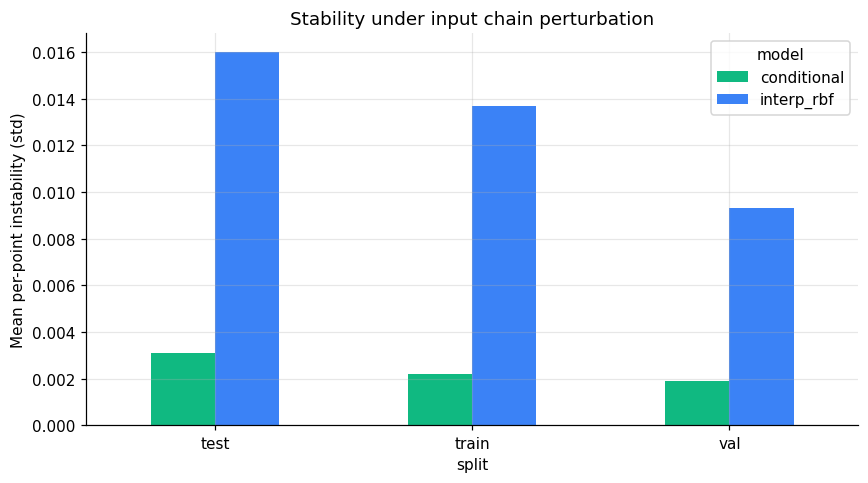

model  conditional  interp_rbf
split                         
test        0.0031      0.0160
train       0.0022      0.0137
val         0.0019      0.0093


In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
inst = struct['mean_instability'].unstack('model')
inst.plot.bar(ax=ax, color=[colors['conditional'], colors['interp_rbf']])
ax.set_ylabel('Mean per-point instability (std)')
ax.set_title('Stability under input chain perturbation')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()
print(inst)


## 7. Per-region structure-diagnostic heatmaps

Pre-rendered as PNGs by the runner. These show, for each (maturity ×
moneyness) cell, the no-arb violation density and the masking instability.


=== Interp RBF — test split ===


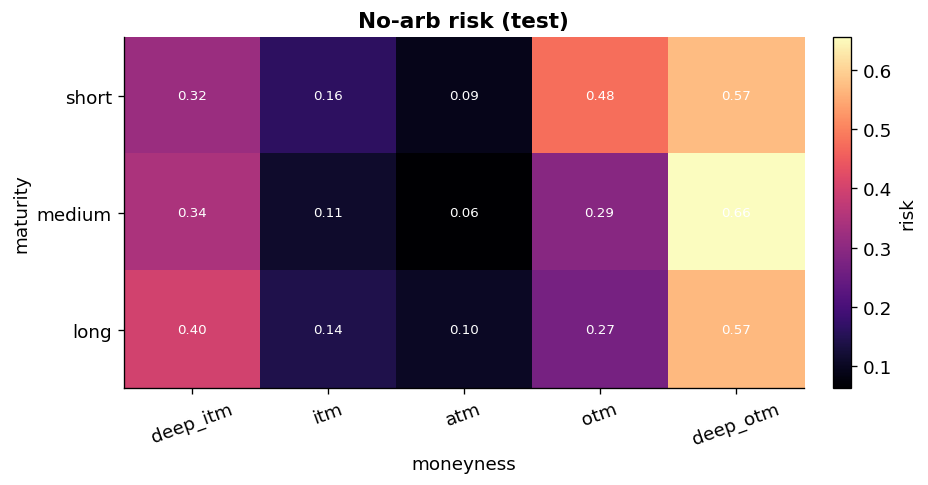

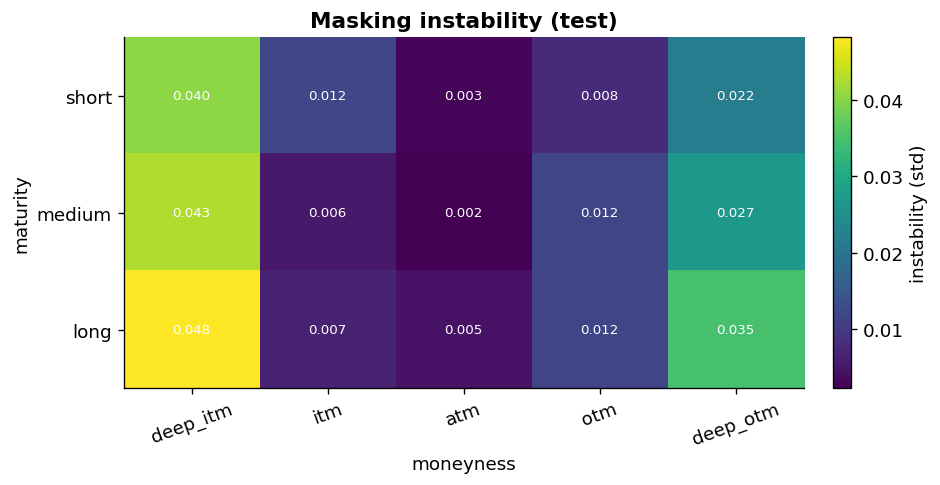

=== Conditional (W3) — test split ===


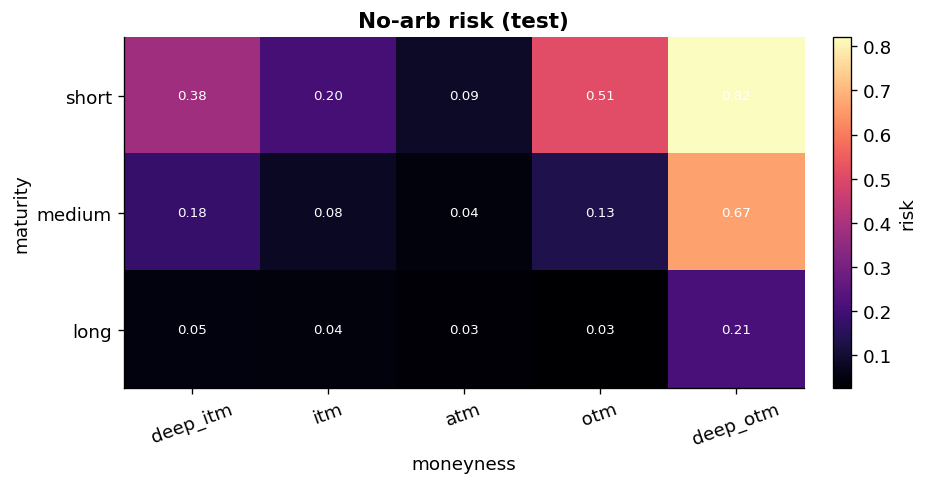

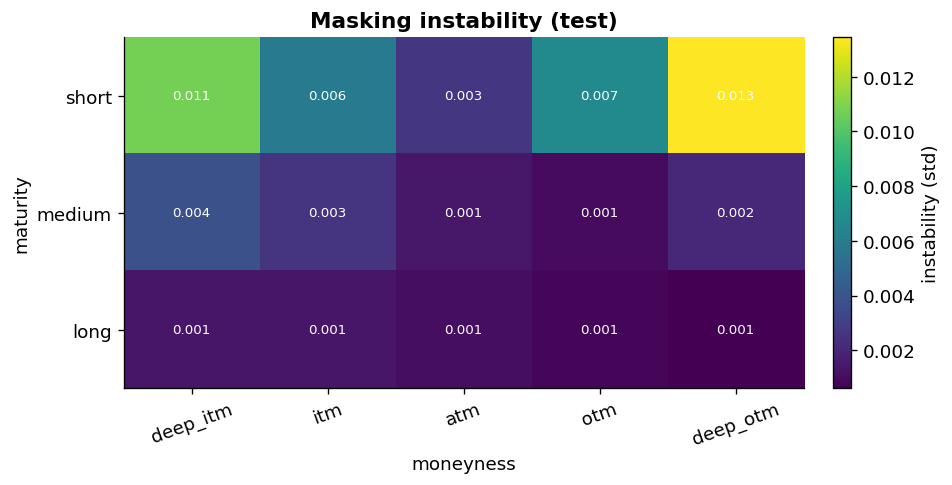

In [13]:
from IPython.display import Image, display
print('=== Interp RBF — test split ===')
display(Image(filename=str(RESULTS / f'structure_diagnostics_{TAG}_interp_rbf_test_risk.png')))
display(Image(filename=str(RESULTS / f'structure_diagnostics_{TAG}_interp_rbf_test_instability.png')))
print('=== Conditional (W3) — test split ===')
display(Image(filename=str(RESULTS / f'structure_diagnostics_{TAG}_conditional_test_risk.png')))
display(Image(filename=str(RESULTS / f'structure_diagnostics_{TAG}_conditional_test_instability.png')))


## 8. Conditional training dynamics — 50 epochs / 3 m 40 s on GPU

Parsed from the training log committed at
`../artifacts/logs/cond_train_20260523_075616.log`.

In [14]:
import re
log = (Path('../artifacts/logs/cond_train_20260523_075616.log')).read_text()
rows = []
for m in re.finditer(
    r'Epoch\s+(\d+)/\d+\s+train_loss=([\d.]+)\s+val_loss=([\d.]+)\s+'
    r'val_obs_mae=([\d.]+)\s+val_unobs_mae=([\d.]+)\s+lr=([\deE.+-]+)\s+\(([\d.]+)s\)',
    log):
    rows.append({
        'epoch': int(m.group(1)),
        'train_loss': float(m.group(2)),
        'val_loss': float(m.group(3)),
        'val_obs_mae': float(m.group(4)),
        'val_unobs_mae': float(m.group(5)),
        'lr': float(m.group(6)),
        'epoch_time_s': float(m.group(7)),
    })
hist = pd.DataFrame(rows)
print(f'Logged epochs: {len(hist)} (script prints every 5 + final)')
hist.head()


Logged epochs: 11 (script prints every 5 + final)


,epoch,train_loss,val_loss,val_obs_mae,val_unobs_mae,lr,epoch_time_s
0,1,0.033374,0.039895,0.132361,0.132288,0.001,4.6
1,5,0.019575,0.023175,0.094568,0.094492,0.001,4.2
2,10,0.012487,0.016825,0.079014,0.079007,0.001,4.1
3,15,0.010725,0.014912,0.071420,0.071379,0.001,4.3
4,20,0.010671,0.012743,0.065138,0.065151,0.001,4.2


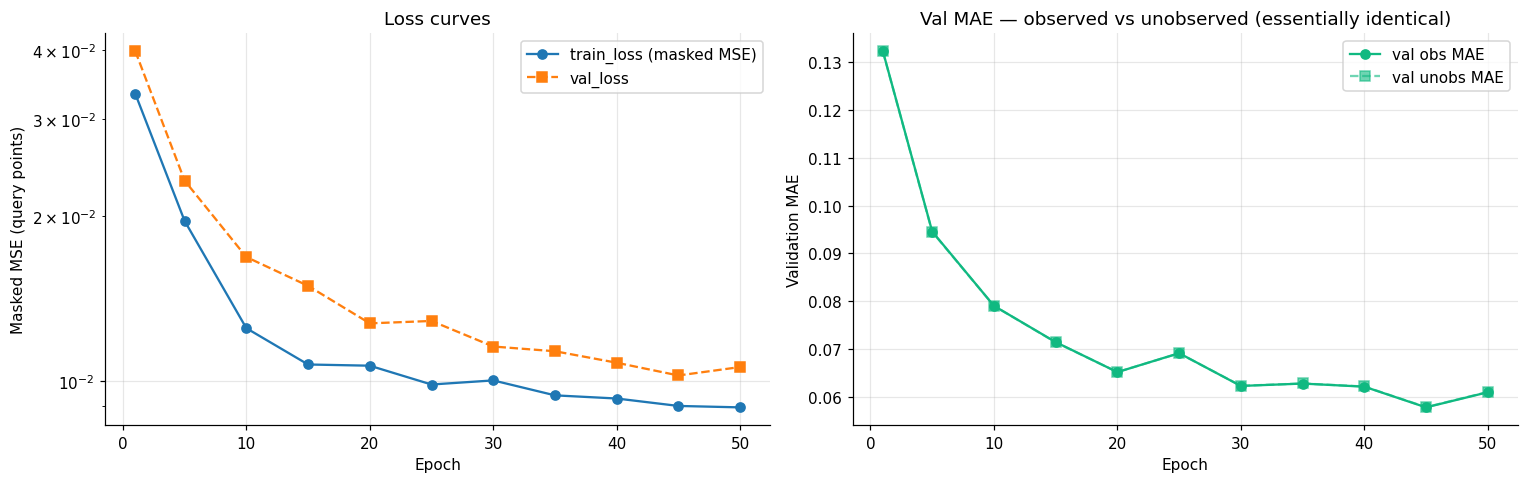

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.plot(hist['epoch'], hist['train_loss'], 'o-', label='train_loss (masked MSE)')
ax.plot(hist['epoch'], hist['val_loss'], 's--', label='val_loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Masked MSE (query points)')
ax.set_title('Loss curves')
ax.set_yscale('log'); ax.legend()

ax = axes[1]
ax.plot(hist['epoch'], hist['val_obs_mae'], 'o-', color=colors['conditional'],
        label='val obs MAE')
ax.plot(hist['epoch'], hist['val_unobs_mae'], 's--', color=colors['conditional'],
        alpha=0.6, label='val unobs MAE')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation MAE')
ax.set_title('Val MAE — observed vs unobserved (essentially identical)')
ax.legend()
plt.tight_layout(); plt.show()


## 9. Discussion

### What the conditional model is good at

- **Beats Phase 1 MLP by ~21% on test MAE** — confirms the inductive bias
  of *conditioning on the observed chain* is real. The MLP had no chain
  information, just `(k, τ)`; the conditional model knows what *this*
  day's quote pattern looks like.
- **Uniform observed/unobserved MAE** — the model treats observed and
  unobserved query points the same way. That's good for downstream
  consumers who don't know which points were "given" to the model.
- **3 m 40 s training time on a single GPU** — cheap to retrain, easy to
  re-run with different chain-sparsity regimes.

### What it doesn't do

- **Still loses to RBF interp in dense regions** by ~14% on overall test
  MAE. RBF benefits from extremely strong locality bias on smooth
  surfaces; a 85K-param network needs to learn this from scratch.
- **No uncertainty signal yet** — the only confidence ranking we have is
  the oracle abs-error, which is a ceiling, not a deployable signal.
  Epic 2D adds heteroscedastic / ensemble / MC-dropout heads.
- **No explicit no-arbitrage penalty** — the model relies entirely on
  the masked-MSE loss to learn smoothness. Structure-diagnostic
  violation rates tell us whether that's enough.

### Open questions for epic 2D

- Can a reliability head (heteroscedastic or ensemble) close the AURC gap?
- Does an explicit calendar/convexity penalty in the loss improve
  structural soundness without hurting MAE?
- Does a larger latent (`latent_dim=128 or 256`) help in the wings?

## 10. Reproducing this notebook

All inputs live in `artifacts/results/` and `artifacts/logs/`. To
regenerate from a fresh notebook:

```
python3 scripts/generate_phase2c_results_notebook.py
jupyter notebook notebooks/04_phase2c_results.ipynb
```

The full Phase B run on real data (the 11-hour autonomous Pod chain that
produced these CSVs) is documented in `docs/experiments/experiment_journal.md`
under the 2026-05-23 entry.
